## **Business Understanding**

**(I). Context**
> *Objective:*  Saat ini, perusahaan asuransi perjalanan menghadapi tantangan besar dalam mengelola risiko dan mengalokasikan sumber daya secara efisien akibat tingginya ketidakpastian terkait pemegang polis mana yang memiliki kemungkinan besar untuk mengajukan klaim. Tanpa adanya prediksi yang akurat, perencanaan finansial dan mitigasi risiko menjadi kurang optimal.

**(II). Problem Statement**
> *Problem:* Meningkatnya jumlah pemegang polis dan pengajuan klaim membuat perusahaan asuransi perlu mengidentifikasi pelanggan yang berpotensi mengajukan klaim secara lebih dini. Tanpa adanya model prediktif, perusahaan hanya dapat mengetahui adanya klaim setelah pelanggan mengajukannya. Oleh karena itu, diperlukan suatu model machine learning yang mampu memprediksi kemungkinan pelanggan mengajukan klaim berdasarkan data historis untuk mendukung proses pengambilan keputusan dan pengelolaan risiko.

**(III). Goals**
> *Goals:* Mengembangkan model machine learning klasifikasi yang mampu memprediksi pelanggan yang mengajukan klaim berdasarkan data historis asuransi perjalanan. Model ini diharapkan dapat membantu perusahaan dalam melakukan identifikasi dini terhadap pelanggan yang berpotensi mengajukan klaim sehingga proses pengelolaan risiko dan perencanaan operasional dapat dilakukan secara lebih cepat, konsisten, dan efisien.

**(IV). Analytical Approach**
> *Goals:* Karena variabel target terdiri dari dua kelas, yaitu 0 (klaim ditolak) dan 1 (klaim diterima), maka permasalahan ini termasuk ke dalam kasus klasifikasi biner (binary classification). Model machine learning klasifikasi akan dikembangkan untuk memprediksi hasil pengajuan klaim berdasarkan data historis.

**(IV). Metric Evaluation (Business Metric, Machine Learning Evaluation Metric)**
> *Machine Learning Metrics:* Dikarenakan datapoint target memiliki sifat imbalanced datasets maka metrik evaluasi yang digunakan adalah Average Precision (PR AUC). Metrik ini sangat baik untuk mengukur performa model dalam mengidentifikasi data dengan kelas yang tidak seimbang.

> *Business Metrics:* Mampu mengindentifikasi data mana yang kedepannya bakal mengajukan klaim.

**(V). Success Criteria**
>  *Machine Learning Performance:* Model memiliki nilai Average Precision (PR AUC yang lebih baik dibandingkan baseline model.


In [338]:
import warnings
warnings.filterwarnings("ignore")

In [339]:
RANDOM_STATE=42

figure_path="../reports/figure"

In [340]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import shap

from feature_engine.outliers import Winsorizer

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    RobustScaler,
    PowerTransformer,
    TargetEncoder,
    LabelEncoder
)

from sklearn.feature_selection import (
    SelectFdr,
    f_classif
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    GradientBoostingClassifier,
)

from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline

from imblearn.over_sampling import  RandomOverSampler

from sklearn.model_selection import (
    train_test_split,
    cross_validate,
    learning_curve
)

from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score
)



In [341]:
df = pd.read_csv("../data/raw/data_travel_insurance_raw.csv")
df.head()

,Agency,Agency Type,Distribution Channel,Product Name,Gender,Duration,Destination,Net Sales,Commision (in value),Age,Claim
0,C2B,Airlines,Online,Annual Silver Plan,F,365,SINGAPORE,216.0,54.0,57,No
1,EPX,Travel Agency,Online,Cancellation Plan,NaN,4,MALAYSIA,10.0,0.0,33,No
2,JZI,Airlines,Online,Basic Plan,M,19,INDIA,22.0,7.7,26,No
3,EPX,Travel Agency,Online,2 way Comprehensive Plan,NaN,20,UNITED STATES,112.0,0.0,59,No
4,C2B,Airlines,Online,Bronze Plan,M,8,SINGAPORE,16.0,4.0,28,No


In [342]:
x = df.drop("Claim", axis=1)
y = df["Claim"]

In [343]:
num_features = [feature for feature in x.columns if x[feature].dtype != 'O']
cat_features = [feature for feature in x.columns if x[feature].dtype == 'O']

## 1. Data Cleaning (Before Entering Pipeline Model)

**1.1 Rename Column (Optional)**

In [344]:
df = df.rename(columns={
    "Commision (in value)": "Commission"
})

In [345]:
df.columns

Index(['Agency', 'Agency Type', 'Distribution Channel', 'Product Name',
       'Gender', 'Duration', 'Destination', 'Net Sales', 'Commission', 'Age',
       'Claim'],
      dtype='object')

**1.2 Fix Categorical Typo (Optional)**

In [346]:
for i in cat_features:
    print(f"Unique Value Of Columns {i}")
    print(x[i].unique())
    print("="*20 )
    print()

Unique Value Of Columns Agency
['C2B' 'EPX' 'JZI' 'CWT' 'LWC' 'ART' 'CSR' 'SSI' 'RAB' 'KML' 'TST' 'TTW'
 'JWT' 'ADM' 'CCR' 'CBH']

Unique Value Of Columns Agency Type
['Airlines' 'Travel Agency']

Unique Value Of Columns Distribution Channel
['Online' 'Offline']

Unique Value Of Columns Product Name
['Annual Silver Plan' 'Cancellation Plan' 'Basic Plan'
 '2 way Comprehensive Plan' 'Bronze Plan' '1 way Comprehensive Plan'
 'Rental Vehicle Excess Insurance' 'Single Trip Travel Protect Gold'
 'Silver Plan' 'Value Plan' '24 Protect' 'Annual Travel Protect Gold'
 'Comprehensive Plan' 'Ticket Protector' 'Travel Cruise Protect'
 'Single Trip Travel Protect Silver' 'Individual Comprehensive Plan'
 'Gold Plan' 'Annual Gold Plan' 'Child Comprehensive Plan' 'Premier Plan'
 'Annual Travel Protect Silver' 'Single Trip Travel Protect Platinum'
 'Annual Travel Protect Platinum' 'Spouse or Parents Comprehensive Plan'
 'Travel Cruise Protect Family']

Unique Value Of Columns Gender
['F' nan 'M']

Uniqu

**1.3 Data Type Change Needed (Optional)**

**1.4 Remove Unrelevant Columns (Optional)**

In [347]:
df.drop("Gender", axis=1, inplace=True)

**1.5 Drop/Fix Ridiculous Value  (Optional)**

**1.5.1 Drop Duplicates**

In [348]:
df.drop_duplicates(inplace=True)

**1.5.2 Drop Row With Age 0**

In [349]:
df = df[df["Age"] != 0]

**1.5.3 Drop Duration Below 1 (Does Not Make Sense)**

In [350]:
df[df["Net Sales"] < 0]

,Agency,Agency Type,Distribution Channel,Product Name,Duration,Destination,Net Sales,Commission,Age,Claim
94,C2B,Airlines,Online,Annual Silver Plan,365,SINGAPORE,-216.75,54.19,36,No
116,CWT,Travel Agency,Online,Rental Vehicle Excess Insurance,430,AUSTRALIA,-59.40,35.64,41,No
121,CWT,Travel Agency,Online,Rental Vehicle Excess Insurance,77,JAPAN,-29.70,17.82,59,No
199,EPX,Travel Agency,Online,Cancellation Plan,29,HONG KONG,-12.00,0.00,36,No
241,CWT,Travel Agency,Online,Rental Vehicle Excess Insurance,57,AUSTRALIA,-59.40,35.64,28,No
...,...,...,...,...,...,...,...,...,...,...
43694,EPX,Travel Agency,Online,2 way Comprehensive Plan,140,UNITED STATES,-98.00,0.00,29,No
43743,CWT,Travel Agency,Online,Rental Vehicle Excess Insurance,23,MALAYSIA,-29.70,17.82,29,No
43751,EPX,Travel Agency,Online,2 way Comprehensive Plan,147,SPAIN,-68.00,0.00,36,No
43858,EPX,Travel Agency,Online,Cancellation Plan,49,UNITED KINGDOM,-68.00,0.00,36,No


In [351]:
df = df[df["Duration"] > 0]

**1.6 Standardize Categorical Value (Optional)**

**1.7 Domain Knowledge Feature (Optional)**

**1.7.1 Refund Is Made When Net Sales Less Then 0**

In [352]:
df["Is Refund"] = np.where(
    df["Net Sales"] < 0,
    "Yes",
    "No"
)

**1.7.2 Suspected Fraud Insurance Where Net Sales Is Negatif But Commision Is Still Received**

In [353]:
df["Suspected Fraud"] = np.where(
    (df["Is Refund"] == "Yes") & (df["Commission"] > 0),
    "Yes",
    "No"
)

**1.7.3 Calculate Commision Rate Where Net Sales Is Larger Then 0, But If Lesser Then 0 Represent As 0**

In [354]:
df["Commission Rate"] = np.where(
    df["Net Sales"] > 0,
    df["Commission"] / df["Net Sales"],
    0 
)

**1.8 Standardize Target/Dependent Feature (Optional)**

In [355]:
df_interim = df.copy()

le = LabelEncoder()
df_interim["Claim"] =  le.fit_transform(df_interim["Claim"])

**1.8 Export To CSV**

In [356]:
df_interim.to_csv("../data/interim/data_travel_insurance_interim.csv", index=False)

In [357]:
x = df_interim.drop("Claim", axis=1)
y = df["Claim"]

In [358]:
num_features = [feature for feature in x.columns if x[feature].dtype != 'O']
cat_features = [feature for feature in x.columns if x[feature].dtype == 'O']

## 2. Data Understanding

**2.1 General Information**

In [359]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 39286 entries, 0 to 44327
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Agency                39286 non-null  object 
 1   Agency Type           39286 non-null  object 
 2   Distribution Channel  39286 non-null  object 
 3   Product Name          39286 non-null  object 
 4   Duration              39286 non-null  int64  
 5   Destination           39286 non-null  object 
 6   Net Sales             39286 non-null  float64
 7   Commission            39286 non-null  float64
 8   Age                   39286 non-null  int64  
 9   Claim                 39286 non-null  object 
 10  Is Refund             39286 non-null  object 
 11  Suspected Fraud       39286 non-null  object 
 12  Commission Rate       39286 non-null  float64
dtypes: float64(3), int64(2), object(8)
memory usage: 4.2+ MB


In [360]:
df.shape

(39286, 13)

In [361]:
df.head()

,Agency,Agency Type,Distribution Channel,Product Name,Duration,Destination,Net Sales,Commission,Age,Claim,Is Refund,Suspected Fraud,Commission Rate
0,C2B,Airlines,Online,Annual Silver Plan,365,SINGAPORE,216.0,54.0,57,No,No,No,0.25
1,EPX,Travel Agency,Online,Cancellation Plan,4,MALAYSIA,10.0,0.0,33,No,No,No,0.00
2,JZI,Airlines,Online,Basic Plan,19,INDIA,22.0,7.7,26,No,No,No,0.35
3,EPX,Travel Agency,Online,2 way Comprehensive Plan,20,UNITED STATES,112.0,0.0,59,No,No,No,0.00
4,C2B,Airlines,Online,Bronze Plan,8,SINGAPORE,16.0,4.0,28,No,No,No,0.25


In [362]:
df.isnull().sum()

Agency                  0
Agency Type             0
Distribution Channel    0
Product Name            0
Duration                0
Destination             0
Net Sales               0
Commission              0
Age                     0
Claim                   0
Is Refund               0
Suspected Fraud         0
Commission Rate         0
dtype: int64

**2.2 Feature Information**


| Column                   | Dtype     | Penjelasan                                                                                                                                                            |
| ------------------------ | --------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Agency**               | `object`  | Nama perusahaan atau agen asuransi yang menjual polis perjalanan. Contoh: `"C2B"`, `"EPX"`, `"JZI"`.                                                                  |
| **Agency Type**          | `object`  | Tipe agen asuransi, misalnya apakah merupakan **airline** atau **travel agency**.                                                                                     |
| **Distribution Channel** | `object`  | Cara produk dijual kepada pelanggan, misalnya melalui **Online** atau **Offline**.                                                                                    |
| **Product Name**         | `object`  | Nama atau jenis produk asuransi perjalanan yang dibeli pelanggan.                                                                                                     |
| **Gender**               | `object`  | Jenis kelamin pelanggan, misalnya **Male** atau **Female**. Terdapat banyak missing value pada kolom ini.                                                             |
| **Duration**             | `int64`   | Lama perlindungan asuransi atau durasi perjalanan dalam satuan **hari**. Nilai yang lebih besar menunjukkan masa perlindungan yang lebih lama.                        |
| **Destination**          | `object`  | Negara atau wilayah tujuan perjalanan yang diasuransikan, misalnya **Singapore**, **Japan**, atau **Australia**.                                                      |
| **Net Sales**            | `float64` | Nilai penjualan bersih polis asuransi. Nilai positif menunjukkan penjualan, sedangkan nilai negatif dapat mengindikasikan pembatalan atau pengembalian dana (refund). |
| **Commision (in value)** | `float64` | Besarnya komisi yang diperoleh agen dari penjualan polis asuransi. Umumnya berbanding lurus dengan nilai penjualan.                                                   |
| **Age**                  | `int64`   | Umur pelanggan dalam satuan **tahun** pada saat membeli polis asuransi.                                                                                               |
| **Is Refund**                | `object`  | Polis data yang net salesnya bernilai negatif                    |
| **Commission Rate**                | `float64`  |  Rate Komisi dari Commision Dibagi Net Sales, namun jika net sales sama dengan 0 atau negatif maka value ini bernilai 0             |
| **Suspected Fraud**                | `object`  | Polis data yang bisa menunjukan ini adalah fraud, dengan indikasi net sales bernilai negatif(refund) dan commision bernilai lebih dari 0                      |
| **Claim**                | `object`  | Variabel target yang menunjukkan apakah pelanggan mengajukan klaim asuransi atau tidak. Contohnya **Yes/No** atau **1/0**, tergantung dataset.                        |



**2.3 Statistics Summary**


In [363]:
df.describe()

,Duration,Net Sales,Commission,Age,Commission Rate
count,39286.000000,39286.000000,39286.00000,39286.000000,39286.000000
mean,52.321819,42.225234,10.38828,39.817798,0.171475
std,113.448306,49.716178,20.35260,13.178069,0.218461
min,1.000000,-357.500000,0.00000,1.000000,0.000000
25%,11.000000,19.000000,0.00000,35.000000,0.000000
50%,25.000000,29.000000,0.00000,36.000000,0.000000
75%,57.000000,50.000000,11.88000,44.000000,0.350000
max,4881.000000,810.000000,283.50000,118.000000,0.650189


## 3. Exploratory Data Analysis (EDA)

**3.1 Univariate Analysis (Target)**
> *Hasil:* Dari hasil univariate analysis ke target, distribusi target terindikasi imbalanced dataset.


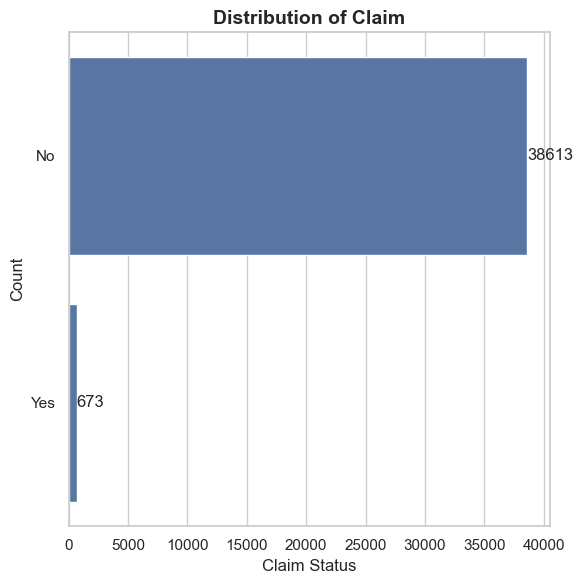

In [364]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(6, 6))

ax = sns.countplot(
   y
)

for container in ax.containers:
    ax.bar_label(container)

ax.set_title("Distribution of Claim", fontsize=14, fontweight="bold")
ax.set_xlabel("Claim Status")
ax.set_ylabel("Count")

plt.tight_layout()

plt.savefig(f"{figure_path}/univariate/target/claim_distribution", dpi=300, bbox_inches="tight")
    
plt.show()

**3.2 Univariate Analysis (Numeric)**


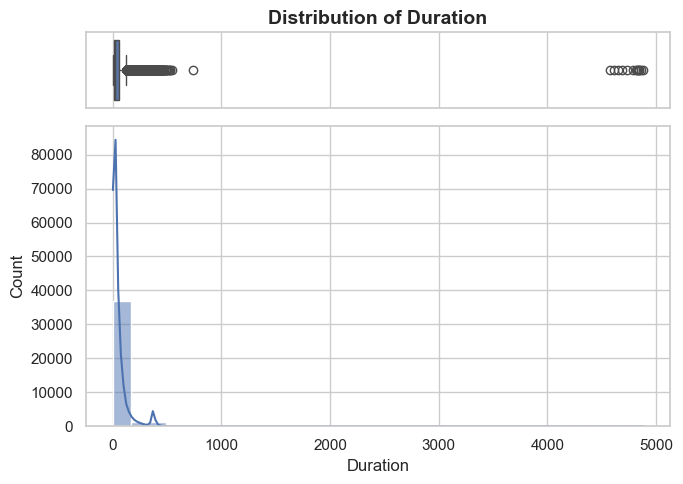

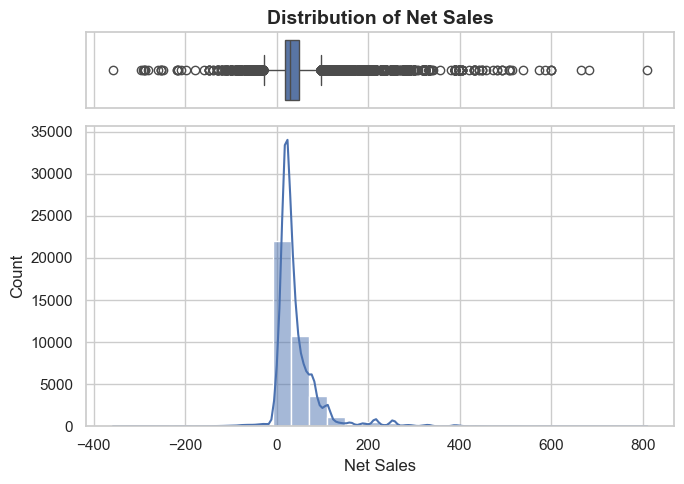

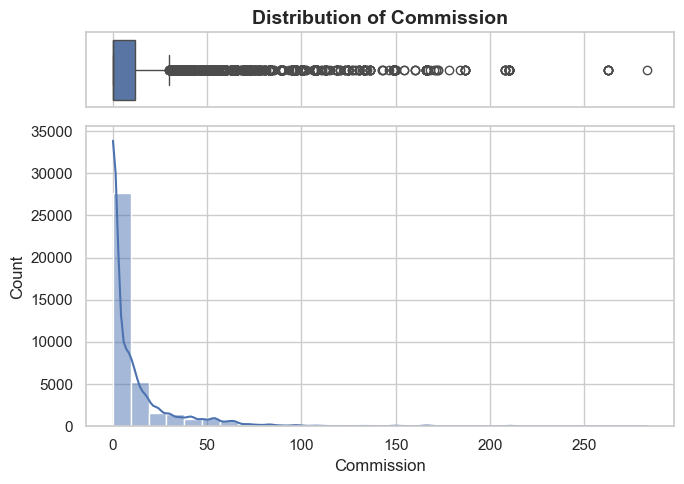

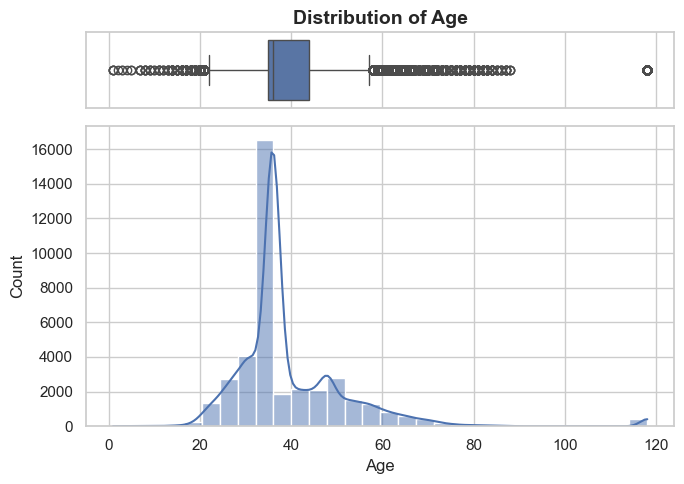

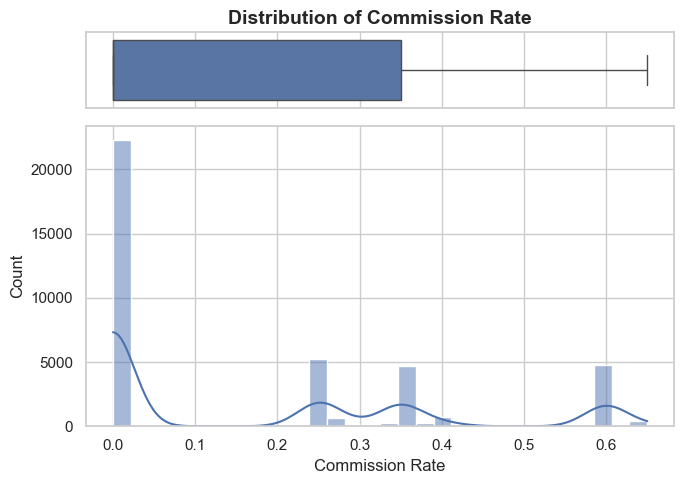

In [365]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot style
sns.set_theme(style="whitegrid")

for feature in num_features:

    fig, (ax_box, ax_hist) = plt.subplots(
        2, 1, 
        figsize=(7, 5), 
        sharex=True, 
        gridspec_kw={"height_ratios": (0.2, 0.8)}
    )

    sns.boxplot(
        x=x[feature],
        ax=ax_box
    )
    ax_box.set(xlabel='') 
    
    ax_box.set_title(
        f"Distribution of {feature}", 
        fontsize=14, 
        fontweight="bold"
    )

    sns.histplot(
        x=x[feature],
        bins=30,
        kde=True,
        ax=ax_hist
    )

    ax_hist.set_xlabel(feature)
    ax_hist.set_ylabel("Count")

    plt.tight_layout()

    plt.savefig(
        f"{figure_path}/univariate/numeric/{feature.lower().replace(' ', '_')}_hist_boxplot.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

**3.3 Univariate Analysis (Kategorik)**


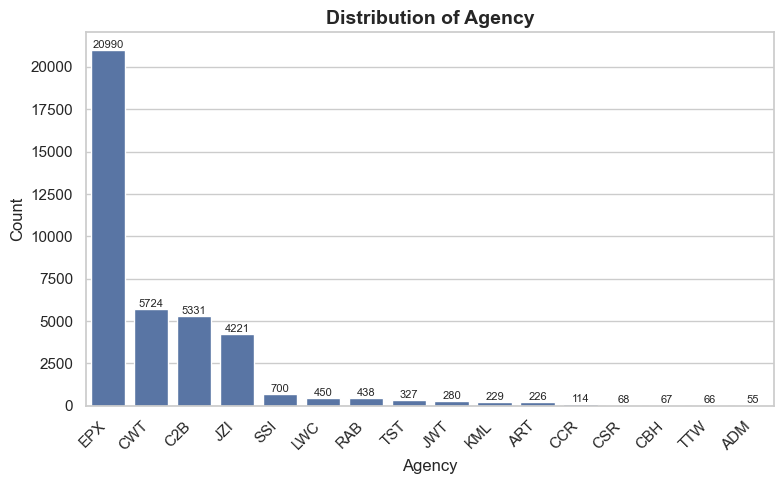

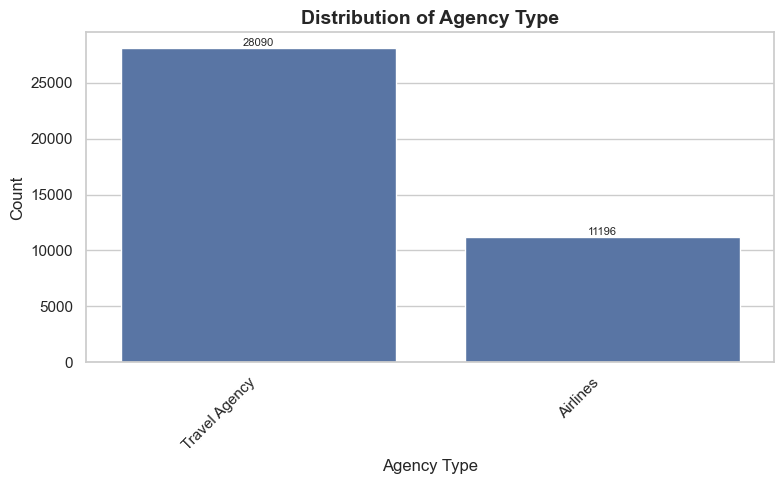

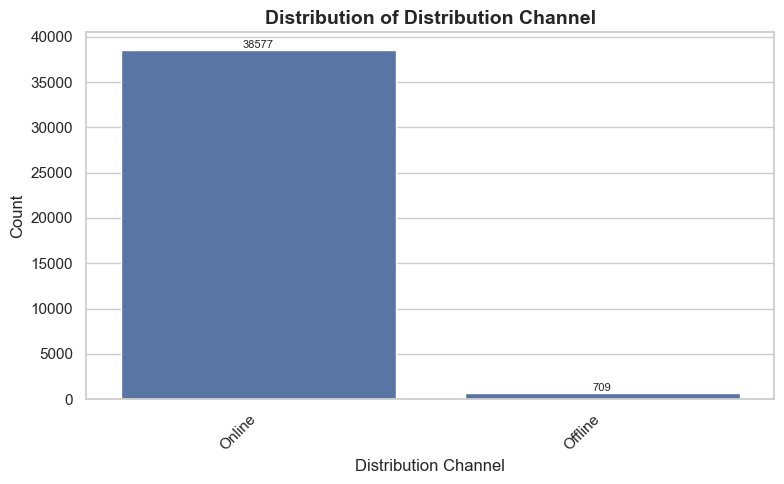

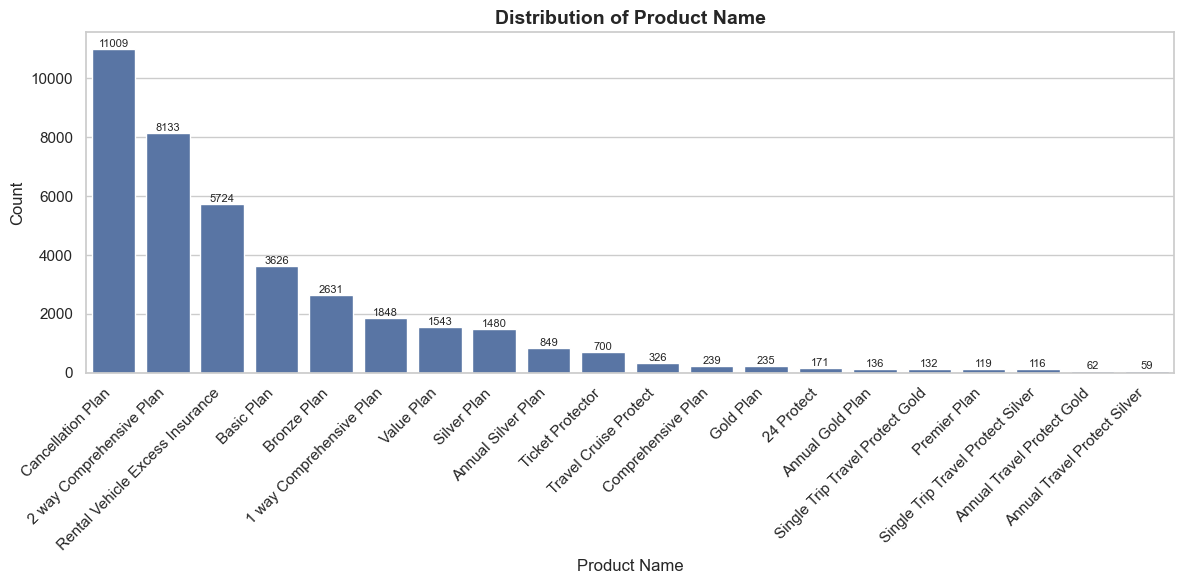

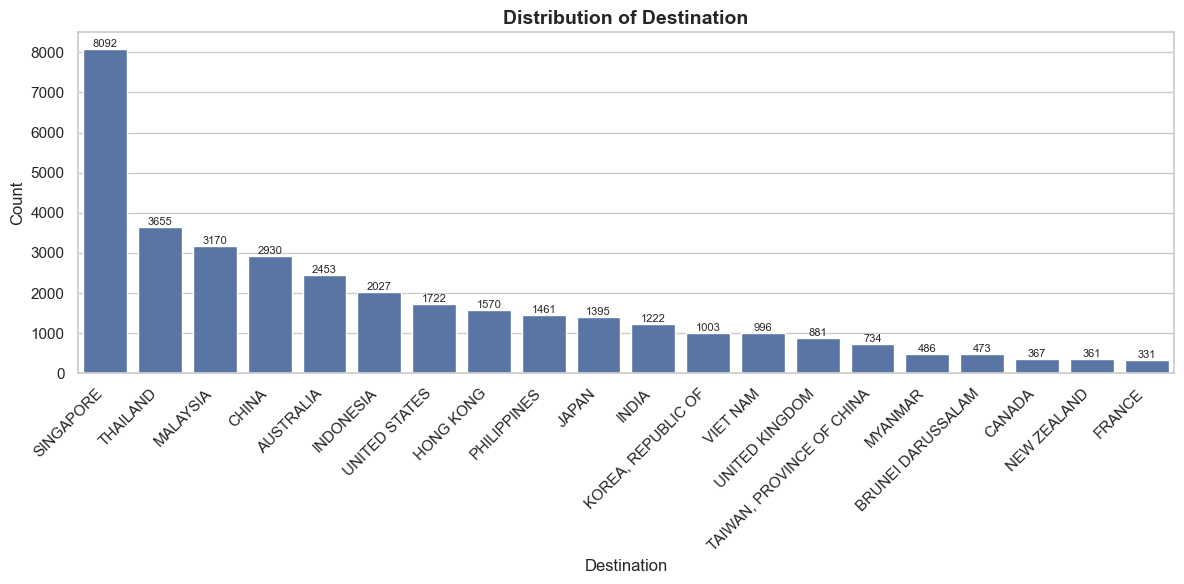

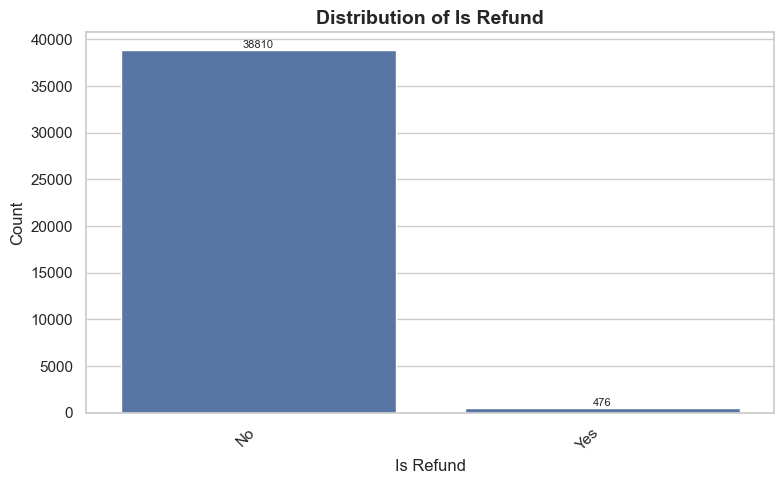

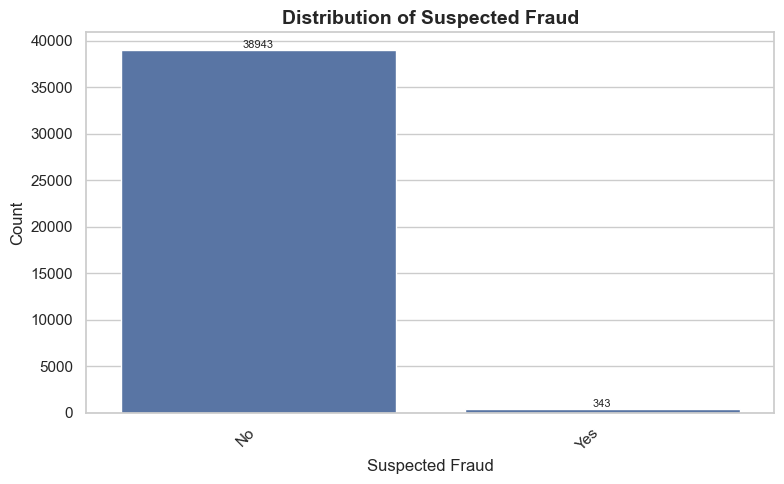

In [366]:
sns.set_theme(style="whitegrid")

for feature in cat_features:
    
    n_categories = x[feature].nunique()

    # Limit categories if too many
    if n_categories > 20:
        order = x[feature].value_counts().nlargest(20).index
        figsize = (12, 6)
    else:
        order = x[feature].value_counts().index
        figsize = (max(8, n_categories * 0.5), 5)

    plt.figure(figsize=figsize)

    ax = sns.countplot(
        x=x[feature],
        order=order
    )

    # Add count labels
    for container in ax.containers:
        ax.bar_label(container, fontsize=8)

    # Rotate x labels
    plt.xticks(rotation=45, ha="right")

    # Title and labels
    plt.title(f"Distribution of {feature}", fontsize=14, fontweight="bold")
    plt.xlabel(feature)
    plt.ylabel("Count")

    plt.tight_layout()


    plt.savefig(
        f"{figure_path}/univariate/categoric/{feature.lower().replace(' ', '_')}_countplot.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

**3.4 Bivariate Analaysis (Kategorik To Target)**


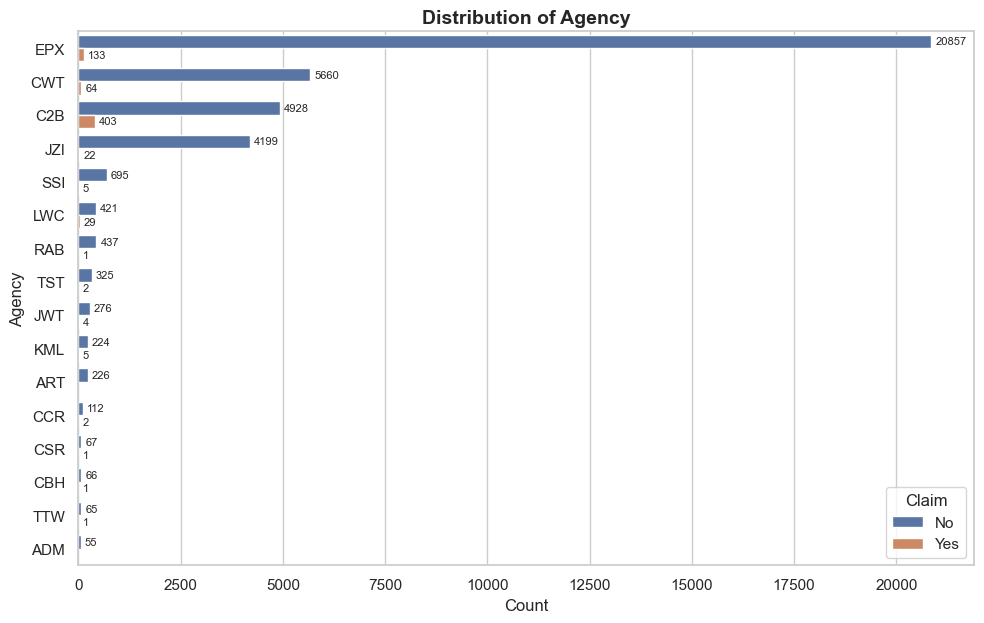

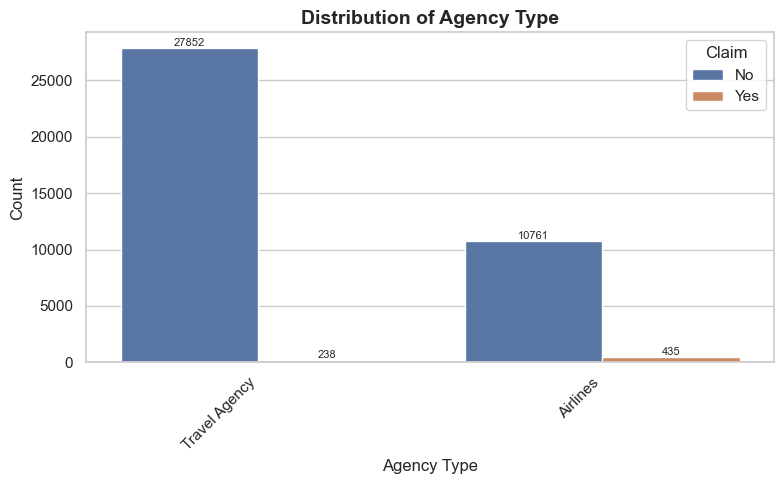

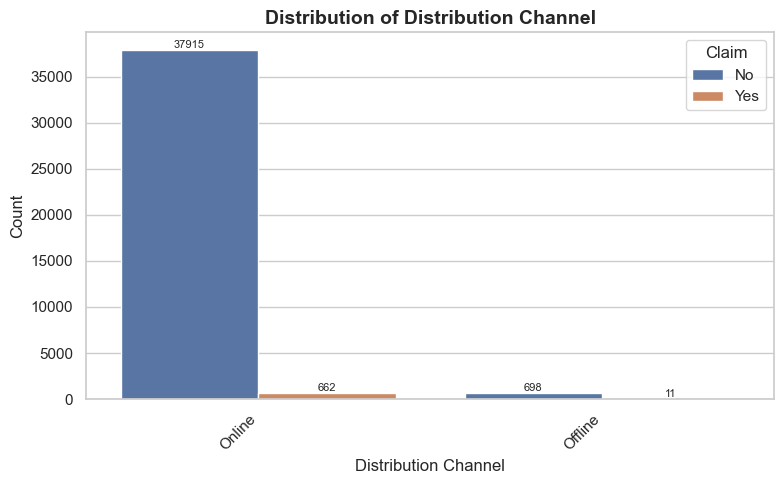

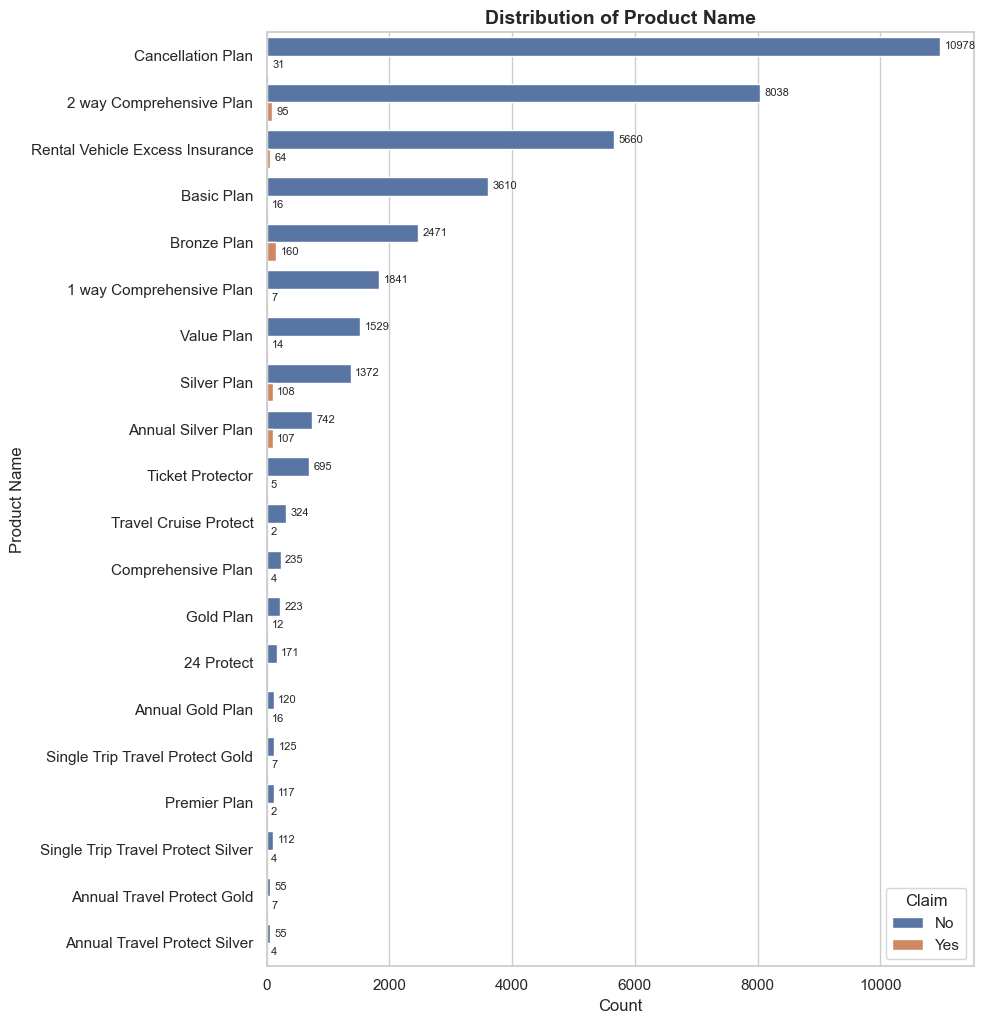

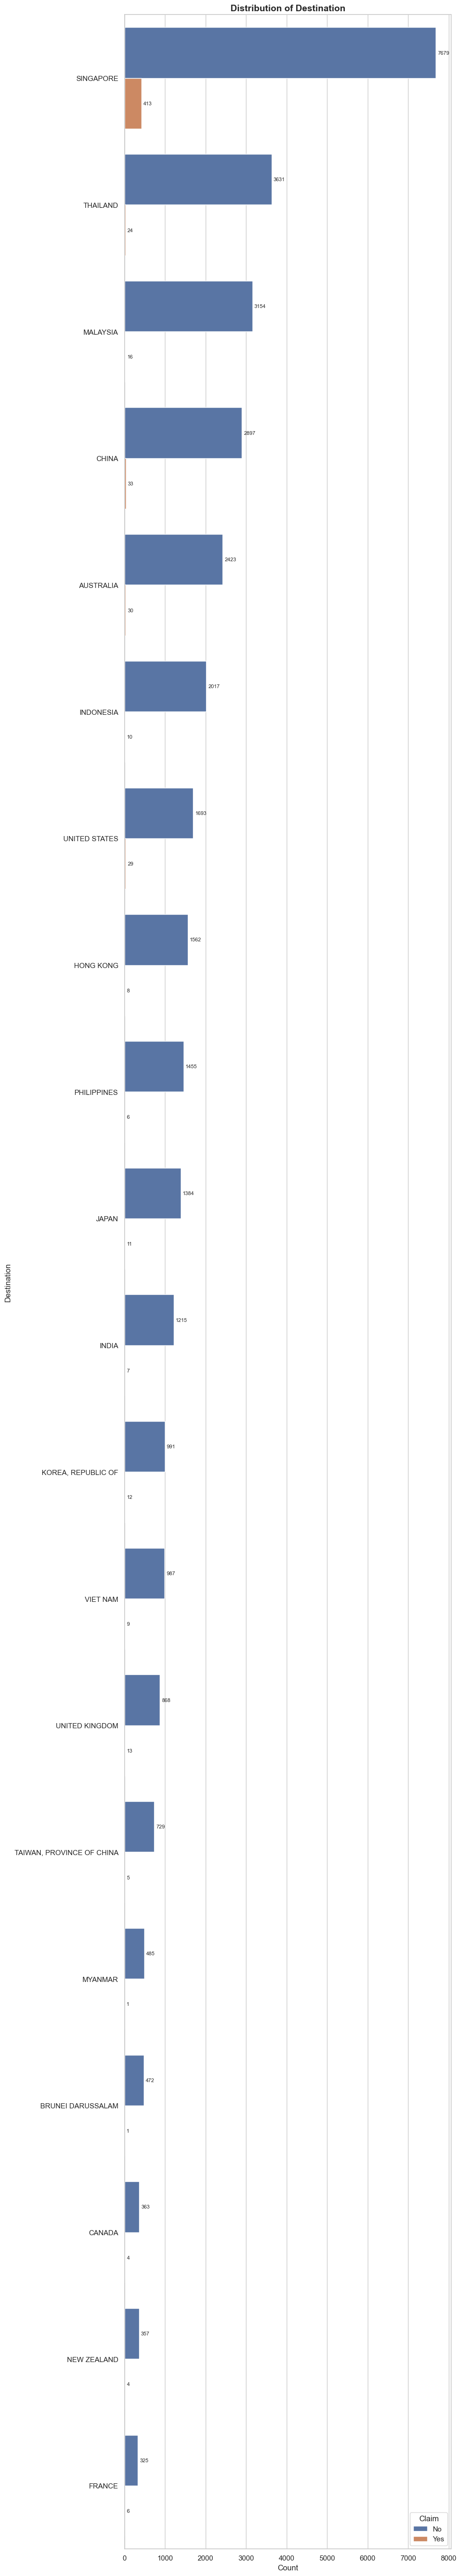

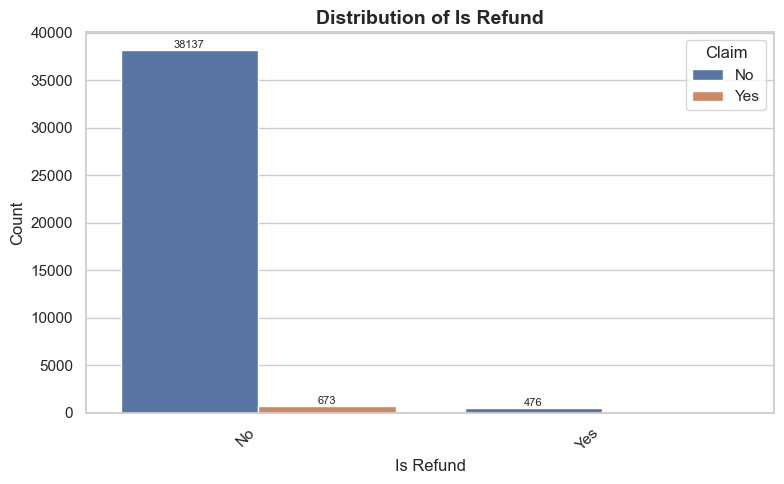

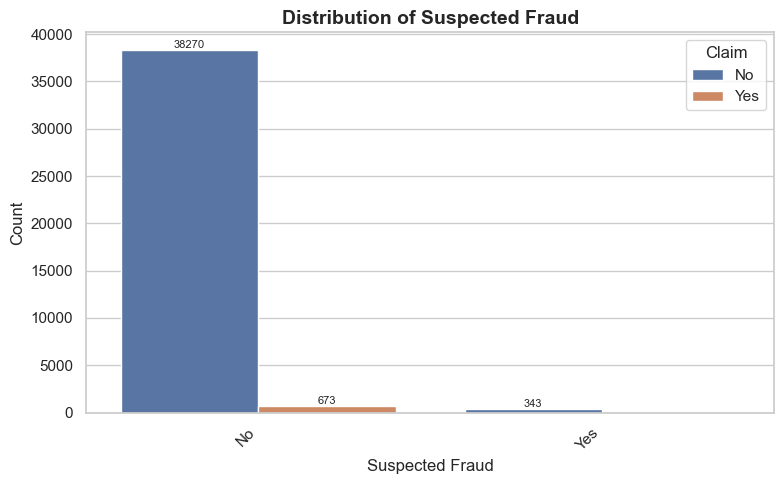

In [367]:
sns.set_theme(style="whitegrid")

for feature in cat_features:
    
    n_categories = x[feature].nunique()

    if n_categories > 20:
        order = x[feature].value_counts().nlargest(20).index
    else:
        order = x[feature].value_counts().index

    if n_categories > 10:
        figsize = (10, max(6, n_categories * 0.4)) 
        plt.figure(figsize=figsize)
        
        ax = sns.countplot(
            y=x[feature],
            hue=y,
            order=order
        )
        
        for container in ax.containers:
            ax.bar_label(container, fontsize=8, padding=3)
            
        plt.ylabel(feature)
        plt.xlabel("Count")
        
    else:
        figsize = (max(8, n_categories * 0.5), 5)
        plt.figure(figsize=figsize)
        
        ax = sns.countplot(
            x=x[feature],
            hue=y,
            order=order
        )
            
        for container in ax.containers:
            ax.bar_label(container, fontsize=8)

        plt.xticks(rotation=45, ha="right")
        
        plt.xlabel(feature)
        plt.ylabel("Count")

    plt.title(f"Distribution of {feature}", fontsize=14, fontweight="bold")
    plt.tight_layout()

    plt.savefig(
        f"{figure_path}/bivariate/categoric/{feature.lower().replace(' ', '_')}_countplot.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

**3.5 Bivariate Analaysis (Numeric To Target)**


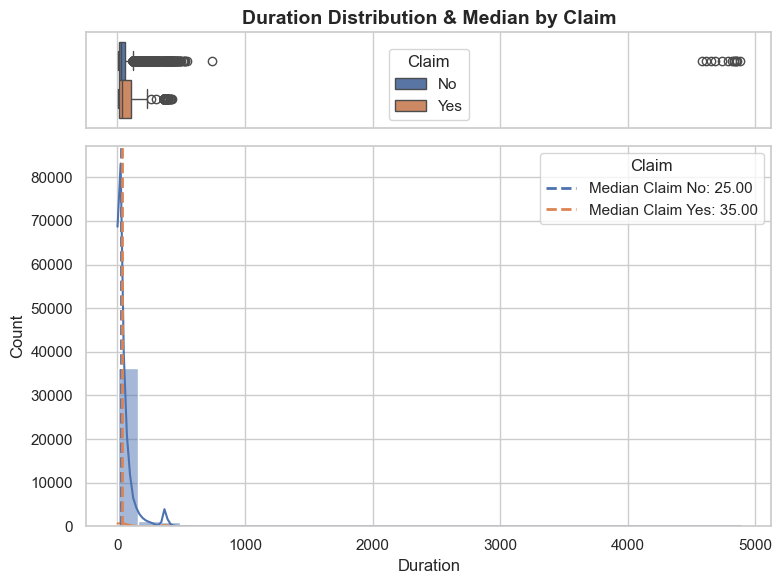

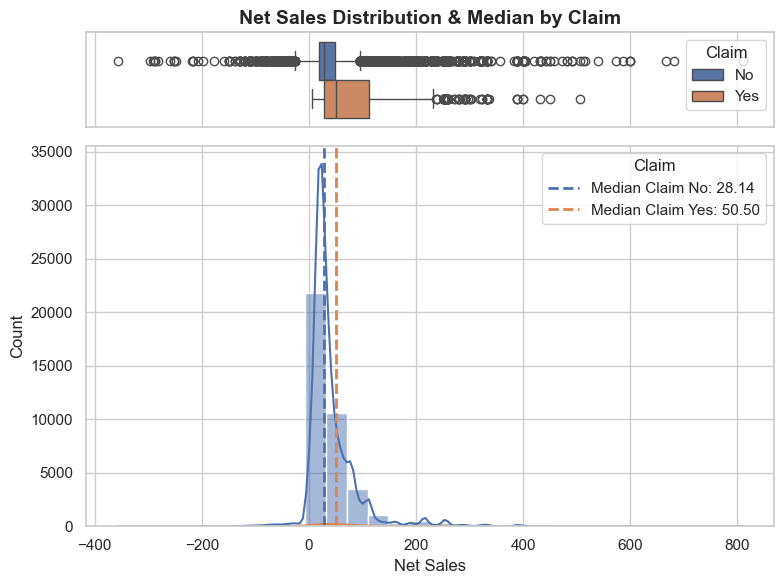

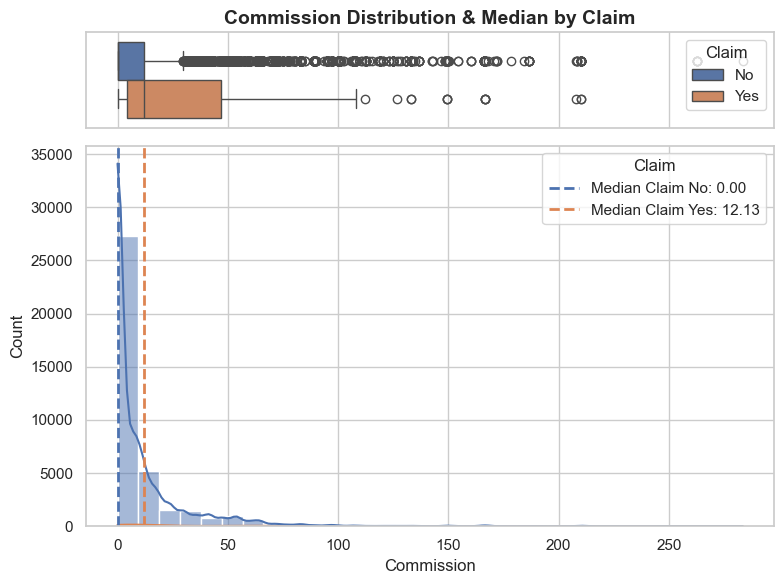

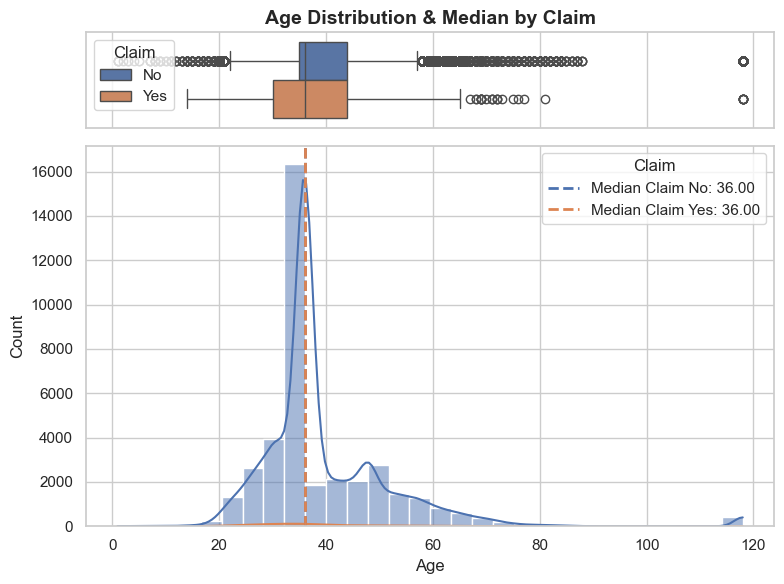

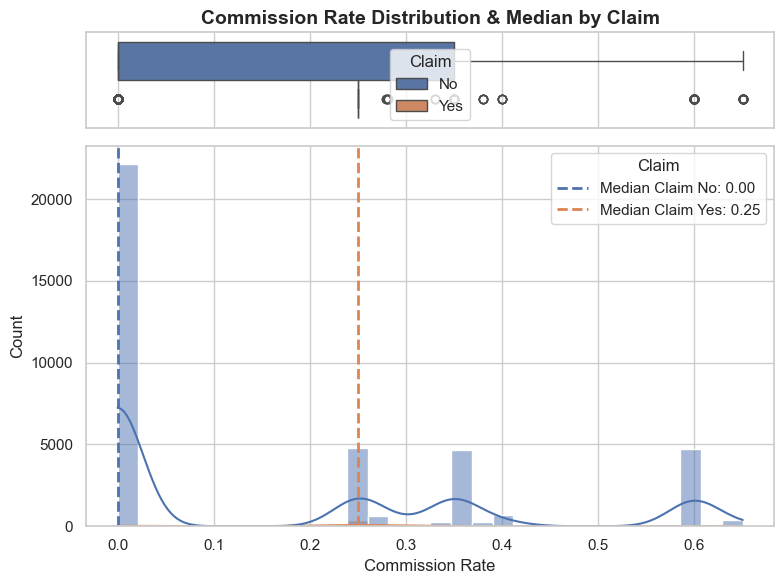

In [368]:
sns.set_theme(style="whitegrid")

for feature in num_features:
    
    fig, (ax_box, ax_hist) = plt.subplots(
        2, 1, 
        figsize=(8, 6), 
        sharex=True, 
        gridspec_kw={"height_ratios": (0.2, 0.8)}
    )

    sns.boxplot(
        x=x[feature],
        hue=y,
        ax=ax_box
    )
    ax_box.set(xlabel='') 
    
    ax_box.set_title(
        f"{feature} Distribution & Median by Claim",
        fontsize=14,
        fontweight="bold"
    )

    sns.histplot(
        x=x[feature],
        hue=y,
        bins=30,
        kde=True,
        ax=ax_hist
    )

    colors = sns.color_palette(n_colors=y.nunique())
    unique_targets = sorted(y.unique())
    
    for target, color in zip(unique_targets, colors):
        median_val = x[y == target][feature].median()
        ax_hist.axvline(
            median_val, 
            color=color, 
            linestyle="--", 
            linewidth=2, 
            label=f"Median Claim {target}: {median_val:.2f}"
        )

    ax_hist.legend(title=y.name if hasattr(y, 'name') else 'Target')
    ax_hist.set_xlabel(feature)
    ax_hist.set_ylabel("Count")

    plt.tight_layout()

    plt.savefig(
        f"{figure_path}/bivariate/numeric/{feature.lower().replace(' ', '_')}_perfect_analysis.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

**3.6 Correlation & Multicollinearity**

**3.6.1 Correlation Check (Visual Check & Threholds Check)**
> *Hasil:* dari hasil analisis korelasi yang ditampilkan menggunakan heatmap kita bisa memakai guidelines dibawah ini.

| Nilai Korelasi | Aksi |
|-------------------|--------|
| < 0.5             | Aman |
| 0.5 - 0.8         | Investigasi Fitur |
| > 0.8             | Boleh Dihapus |
| > 0.9             | Layak Dihapus |

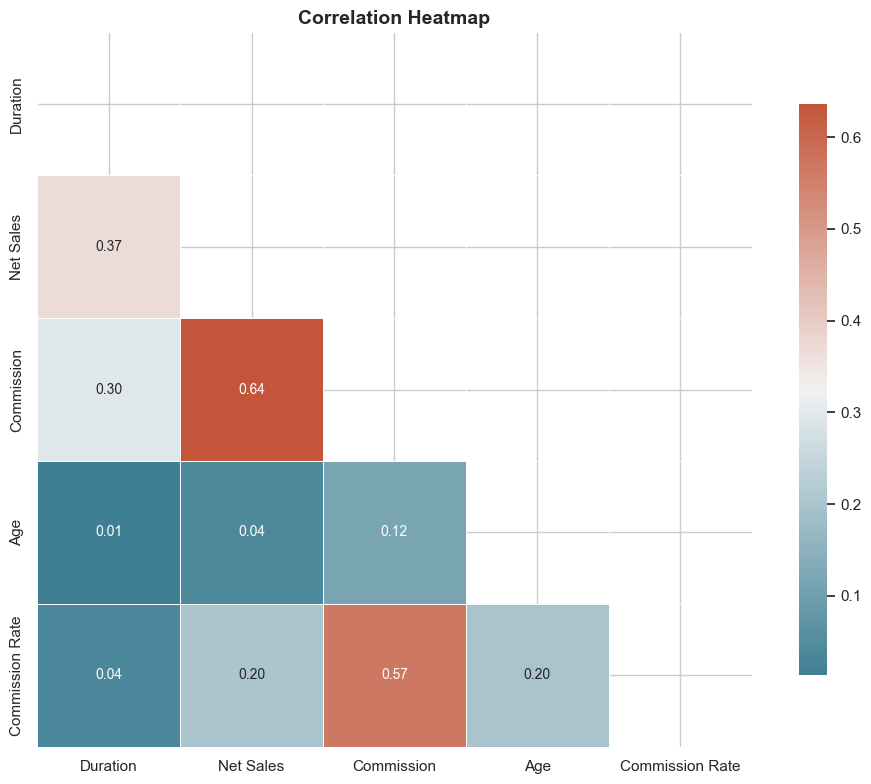

In [369]:
corr_matrix = x.corr(numeric_only=True)

# Buat heatmap dengan styling menarik
plt.figure(figsize=(10, 8))

# Custom diverging colormap
cmap = sns.diverging_palette(220, 20, as_cmap=True)

# Buat mask segitiga atas agar lebih clean
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Heatmap
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap=cmap,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    annot_kws={"fontsize": 10}
)

plt.title("Correlation Heatmap", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [370]:
def check_correlated_independent_feature(dataset, threshold):
    col_correlated = set()
    corr_matrix = dataset.corr(numeric_only=True)
    
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j]) > threshold:
                colname = corr_matrix.columns[i]
                col_correlated.add(colname)
                
    return col_correlated

corr_features = check_correlated_independent_feature(x, 0.80)
print("Feature Correlated Check With Thresholds > 0.80:", corr_features)

Feature Correlated Check With Thresholds > 0.80: set()


**3.6.1 Variance Inflation Factor**
> *Hasil:* Seluruh VIF value aman. dikarenakan tidak ada fitur yang memiliki nilai VIF > 10.

| Nilai Korelasi | Aksi |
|-------------------|--------|
| > 10            | Hapus Kolom |
| < 10      | Simpan Kolom (VIF Aman) |

In [371]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_score = pd.DataFrame()

vif_score["Feature"] = x[num_features].columns
vif_score["VIF"] = [
    variance_inflation_factor(x[num_features].values, i)
    for i in range(x[num_features].shape[1])
]

vif_score


,Feature,VIF
0,Duration,1.422640
1,Net Sales,3.038929
2,Commission,3.164687
3,Age,2.328839
4,Commission Rate,2.606625


## **Section 4. Data Preparation**

In [372]:
READ_CSV="../data/interim/data_travel_insurance_interim.csv"
RANDOM_STATE=42

TARGET_TRANSFORM_COLS = ["Destination"]
LOG_TRANSFORM_COLS= ["Duration", "Net Sales"]

In [373]:
df = pd.read_csv(READ_CSV)
df.head()

,Agency,Agency Type,Distribution Channel,Product Name,Duration,Destination,Net Sales,Commission,Age,Claim,Is Refund,Suspected Fraud,Commission Rate
0,C2B,Airlines,Online,Annual Silver Plan,365,SINGAPORE,216.0,54.0,57,0,No,No,0.25
1,EPX,Travel Agency,Online,Cancellation Plan,4,MALAYSIA,10.0,0.0,33,0,No,No,0.00
2,JZI,Airlines,Online,Basic Plan,19,INDIA,22.0,7.7,26,0,No,No,0.35
3,EPX,Travel Agency,Online,2 way Comprehensive Plan,20,UNITED STATES,112.0,0.0,59,0,No,No,0.00
4,C2B,Airlines,Online,Bronze Plan,8,SINGAPORE,16.0,4.0,28,0,No,No,0.25


**4.1 Initialization**

In [374]:
x = df.drop(columns=["Claim"])
y = df["Claim"]

**4.2 Constructing `Training` and `Testing` Data (from `Seen` Dataset) & Handling Imbalanced Dataset** 

In [375]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

In [376]:
NUMERIC_COLS = [features for features in x_train.columns if x_train[features].dtypes != "O"]
CATEGORICAL_COLS = [features for features in x_train.columns if x_train[features].dtypes == "O"]

**4.3 Data Transformation (Feature Engineering)**

In [377]:
numeric_pipeline = Pipeline([
    ("winsorizer_iqr", Winsorizer(capping_method="iqr", fold=1.5)),
    ("RobustScaler", RobustScaler()),
])

numeric_log_pipeline = Pipeline([
    ("power", PowerTransformer(method="yeo-johnson")),
    ("RobustScaler", RobustScaler()),
])

categorical_ohe_pipeline = Pipeline([
    ("OneHotEncoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first"))
 ])

categorical_target_pipeline = Pipeline([
    ("TargetEncoder", TargetEncoder())
])
    
preprocessor = ColumnTransformer(
    [
        ("numeric_pipeline", numeric_pipeline, [c for c in NUMERIC_COLS if c not in LOG_TRANSFORM_COLS]),
        ("numeric_log_pipeline", numeric_log_pipeline, LOG_TRANSFORM_COLS),
        ("categorical_ohe_pipeline", categorical_ohe_pipeline, [c for c in CATEGORICAL_COLS if c not in TARGET_TRANSFORM_COLS]),
        ("categorical_target_pipeline", categorical_target_pipeline, TARGET_TRANSFORM_COLS),
    ],
    remainder="drop"
)   

**4.4 Overview**

## **Section 5. Model Development**

**5.1 Initialization**

In [378]:
def benchmark_models(pipelines, x_train, y_train, cv=5):
    all_cv_result = []

    for name, pipeline in pipelines.items():
        cv_result = cross_validate(
            estimator=pipeline,
            X=x_train, y=y_train,
            cv=cv,
            scoring="average_precision",
            return_train_score=True,
            n_jobs=-1 
        )
        
        pipeline.fit(x_train, y_train)
        


        all_cv_result.append({
            "name": name,
            "mean_ap_train_score": np.mean(cv_result["train_score"]),
            "mean_ap_validate_score": np.mean(cv_result["test_score"]),
            "mean_sd_train_score": np.std(cv_result["train_score"]),
            "mean_sd_validate_score": np.std(cv_result["test_score"]),
        })
        
        

    result_df = pd.DataFrame(all_cv_result).sort_values(
        "mean_ap_validate_score", ascending=False
    ).reset_index(drop=True)

    return result_df

def base_pipeline():
    numeric_pipeline = Pipeline([
        ("winsorizer_iqr", Winsorizer(capping_method="iqr", fold=1.5)),
        ("RobustScaler", RobustScaler()),
    ])

    categorical_ohe_pipeline = Pipeline([
        ("OneHotEncoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first"))
    ])

    preprocessor = ColumnTransformer(
        [
            ("numeric_pipeline", numeric_pipeline, NUMERIC_COLS),
            ("categorical_ohe_pipeline", categorical_ohe_pipeline, CATEGORICAL_COLS),
        ],
        remainder="drop"
    )
    
    return Pipeline(
        [
            ("preprocessor", preprocessor),
            ("classifier", LogisticRegression(random_state=42))
        ]
    )

**5.2 Developing the Model Pipeline**

In [379]:
tuned_pipeline = ImbPipeline([
    ("preprocessor", preprocessor),
    ("feature_selection", SelectFdr(score_func=f_classif, alpha=0.005)),
    ("resampler", RandomOverSampler(random_state=RANDOM_STATE)),
    ("classifier", GradientBoostingClassifier(random_state=RANDOM_STATE))
])
    
best_params = {
    'classifier__learning_rate': 0.020585312110064476,
    'classifier__max_depth': 4,
    'classifier__max_features': 'log2',
    'classifier__min_samples_leaf': 26,
    'classifier__min_samples_split': 42,
    'classifier__n_estimators': 177,
    'classifier__subsample': 0.8227412591061039
}

tuned_pipeline.set_params(**best_params)

,steps,"[('preprocessor', ...), ('feature_selection', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric_pipeline', ...), ('numeric_log_pipeline', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


**6.3 Model Benchmarking (Comparing model base performance)**

In [380]:
logreg_base_pipeline = base_pipeline()
gb_base_pipeline = base_pipeline()
gb_base_pipeline.set_params(classifier=GradientBoostingClassifier(random_state=RANDOM_STATE))

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric_pipeline', ...), ('categorical_ohe_pipeline', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [381]:
pipelines = {
    "Base LogReg": logreg_base_pipeline,
    "Base GB (Default)": gb_base_pipeline,
    "Tuned GB (Optimized)": tuned_pipeline
}

pipelines = {
    "Base LogReg": logreg_base_pipeline,
    "Base GB": gb_base_pipeline,
    "Tuned GB": tuned_pipeline,
}

results = benchmark_models(
    pipelines,
    x_train,
    y_train,
)

results

,name,mean_ap_train_score,mean_ap_validate_score,mean_sd_train_score,mean_sd_validate_score
0,Tuned GB,0.113989,0.094884,0.004236,0.011670
1,Base LogReg,0.087203,0.083697,0.001646,0.006475
2,Base GB,0.217658,0.076417,0.003406,0.006738


**6.5 Analyze Model**

**6.5.1 Test Data AP Score**

The test data AP scores receives an increases if our standpoint is from mean ap validation score. 

In [382]:
tuned_pipeline.fit(x_train, y_train)

y_test_pred_proba = tuned_pipeline.predict_proba(x_test)[:, 1]
print("Average Precision On Test Set:", average_precision_score(y_test, y_test_pred_proba))

Average Precision On Test Set: 0.11373598448459472


**6.5.2 Test Data AP Confusion Matrix**

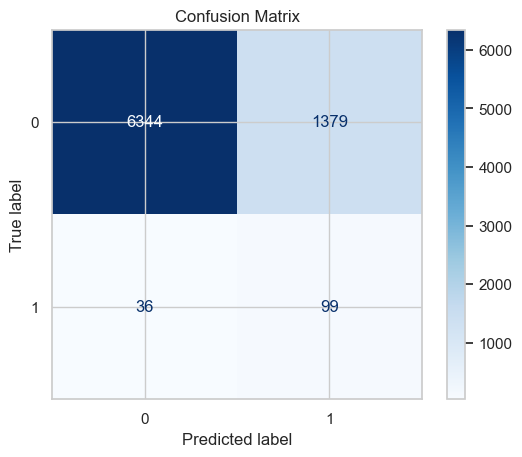

In [383]:
ConfusionMatrixDisplay.from_estimator(
    tuned_pipeline,
    x_test,
    y_test,
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix")
plt.show()

 **6.5.1 Learning Curve**

The learning curve was used to evaluate the model's learning behavior and generalization performance as the training data increased.

**Observations:**
- The training AP gradually decreases as more training samples are added.
- The validation AP steadily improves with additional training data.
- A small gap remains between the training and validation curves, indicating **mild overfitting**.
- Both curves begin to converge toward the end, suggesting that the tuned Gradient Boosting model generalizes reasonably well.

Overall, the learning curve indicates that hyperparameter tuning successfully reduced overfitting compared to the baseline model, although a slight degree of overfitting still exists.

In [384]:
train_sizes, train_scores, valid_scores = learning_curve(
    estimator=tuned_pipeline,
    X=x_train,
    y=y_train,
    cv=5,
    scoring="average_precision",
    train_sizes=np.linspace(0.1, 1.0, 10),
    shuffle=True,
    random_state=42,
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

valid_mean = valid_scores.mean(axis=1)
valid_std = valid_scores.std(axis=1)

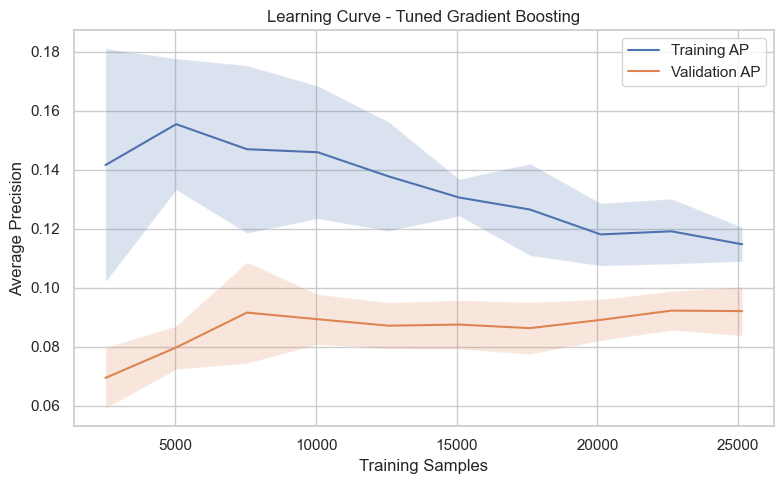

In [385]:
plt.figure(figsize=(8,5))

plt.plot(train_sizes, train_mean, label="Training AP")
plt.plot(train_sizes, valid_mean, label="Validation AP")

plt.fill_between(
    train_sizes,
    train_mean-train_std,
    train_mean+train_std,
    alpha=0.2
)

plt.fill_between(
    train_sizes,
    valid_mean-valid_std,
    valid_mean+valid_std,
    alpha=0.2
)

plt.xlabel("Training Samples")
plt.ylabel("Average Precision")
plt.title("Learning Curve - Tuned Gradient Boosting")
plt.legend()

plt.tight_layout()
plt.show()

**6.6 Thresholds Optimization**

**6.6.1 Visualize PR AUC**

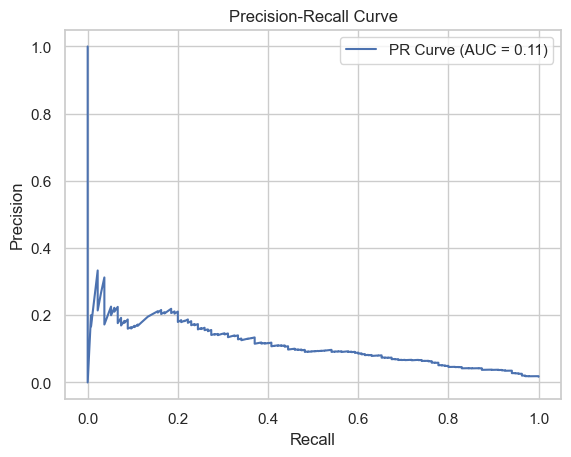

In [386]:
precision, recall, thresholds = precision_recall_curve(y_test, y_test_pred_proba)
auc_pr = average_precision_score(y_test, y_test_pred_proba)

plt.plot(recall, precision, label=f'PR Curve (AUC = {auc_pr:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()


**6.6.2 Threshold Optimization Using Cost Matrix**

The default classification threshold (0.5) may not minimize business cost. Therefore, multiple thresholds were evaluated using a cost matrix.

| Outcome | Business Cost |
|---------|--------------:|
| False Positive (FP) | Rp300,000 (manual review by analyst and legal team) |
| False Negative (FN) | Rp42,000,000 (average travel insurance claim payout) |

For each threshold, the total business cost was calculated as:

`Total Cost = (FP × Rp300,000) + (FN × Rp42,000,000)`

The threshold with the lowest total cost was selected as the final operating threshold.

In [387]:
results = []

cost_fn = 42000000    # Model memprediksi tidak claim, tetapi ternyata claim.
cost_fp = 300000     # Model memprediksi claim, tetapi tidak klaim

for threshold in thresholds:
    y_pred = (y_test_pred_proba >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    total_cost = fn * cost_fn + fp * cost_fp

    results.append({
        "Threshold": threshold,
        "Recall": tp / (tp + fn),
        "Precision": tp / (tp + fp) if (tp + fp) else 0,
        "FP": fp,
        "FN": fn,
        "Total Cost": total_cost
    })

df_threshold = pd.DataFrame(results)
df_threshold.sort_values("Total Cost")[:5]

,Threshold,Recall,Precision,FP,FN,Total Cost
3303,0.288115,0.940741,0.035083,3493,8,1383900000
3302,0.287655,0.940741,0.035064,3495,8,1384500000
3301,0.287594,0.940741,0.035044,3497,8,1385100000
3300,0.287508,0.940741,0.035025,3499,8,1385700000
3299,0.287404,0.940741,0.035015,3500,8,1386000000


**6.6.2 Scoring After Threshold Optimization**

In [388]:
best_threshold = 0.297792
y_pred = (y_test_pred_proba >= best_threshold).astype(int)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Recall After Thresholds Optimization On Test Set:", recall)
print("Precision After Thresholds Optimization On Test Set:", precision)
print("F1 Score After Thresholds Optimization On Test Set:", f1)

Recall After Thresholds Optimization On Test Set: 0.9259259259259259
Precision After Thresholds Optimization On Test Set: 0.035878300803673935
F1 Score After Thresholds Optimization On Test Set: 0.06907985631389886


**6.6.3 Confusions Matrix After Threshold Optimization**

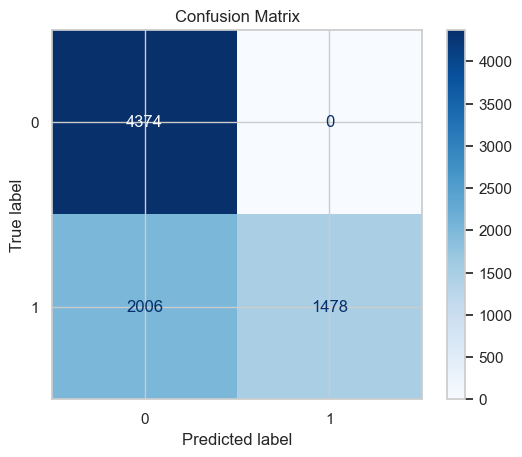

In [389]:
ConfusionMatrixDisplay.from_estimator(
    tuned_pipeline,
    x_test,
    y_pred,
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix")
plt.show()

**6.7 Model Explanation and Interpretation**

**6.7.1 Feature Importances**

In [390]:
features = tuned_pipeline[:2].get_feature_names_out()
features_names = list(map(lambda x: x.split("__")[1],features))
feature_importances = tuned_pipeline.named_steps["classifier"].feature_importances_

df = pd.DataFrame({
    "Feature": features_names,
    "Importance": feature_importances
})

df = df.sort_values("Importance", ascending=True)

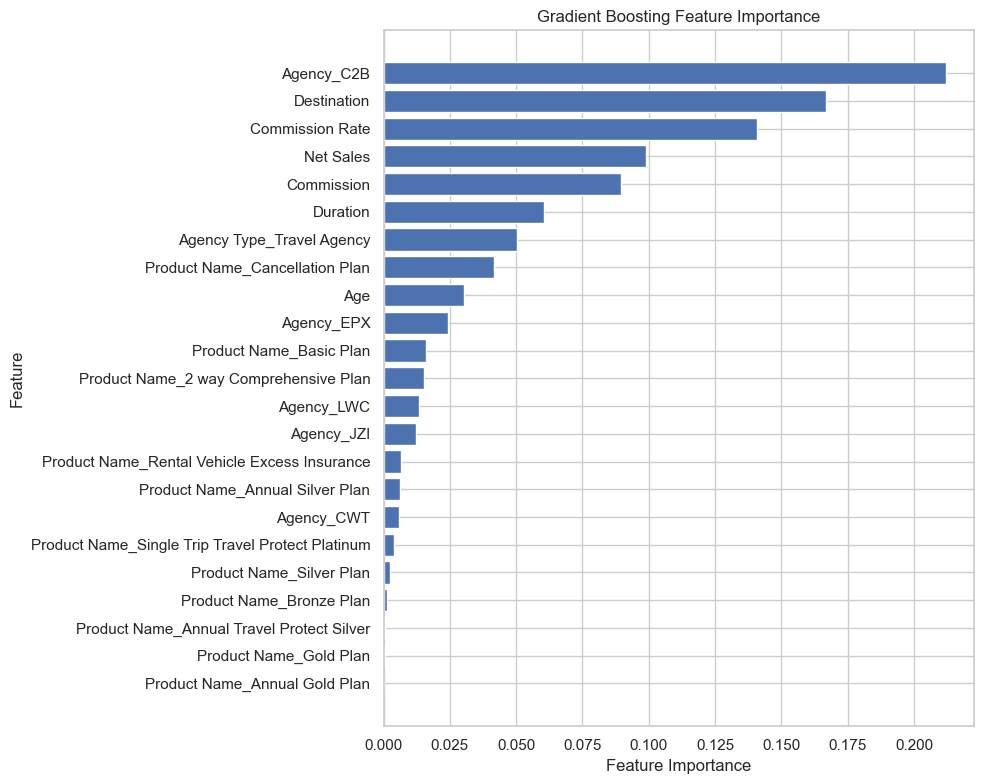

In [391]:
plt.figure(figsize=(10, 8))
plt.barh(df["Feature"], df["Importance"])

plt.title("Gradient Boosting Feature Importance")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()

plt.show()

**6.7.2 SHAP Values (To Find Positive And Negative Impacts)**

In [392]:
x_test_transformed = tuned_pipeline[:2].transform(x_test)

model = tuned_pipeline.named_steps["classifier"]

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(
    x_test_transformed,
    check_additivity=False
)

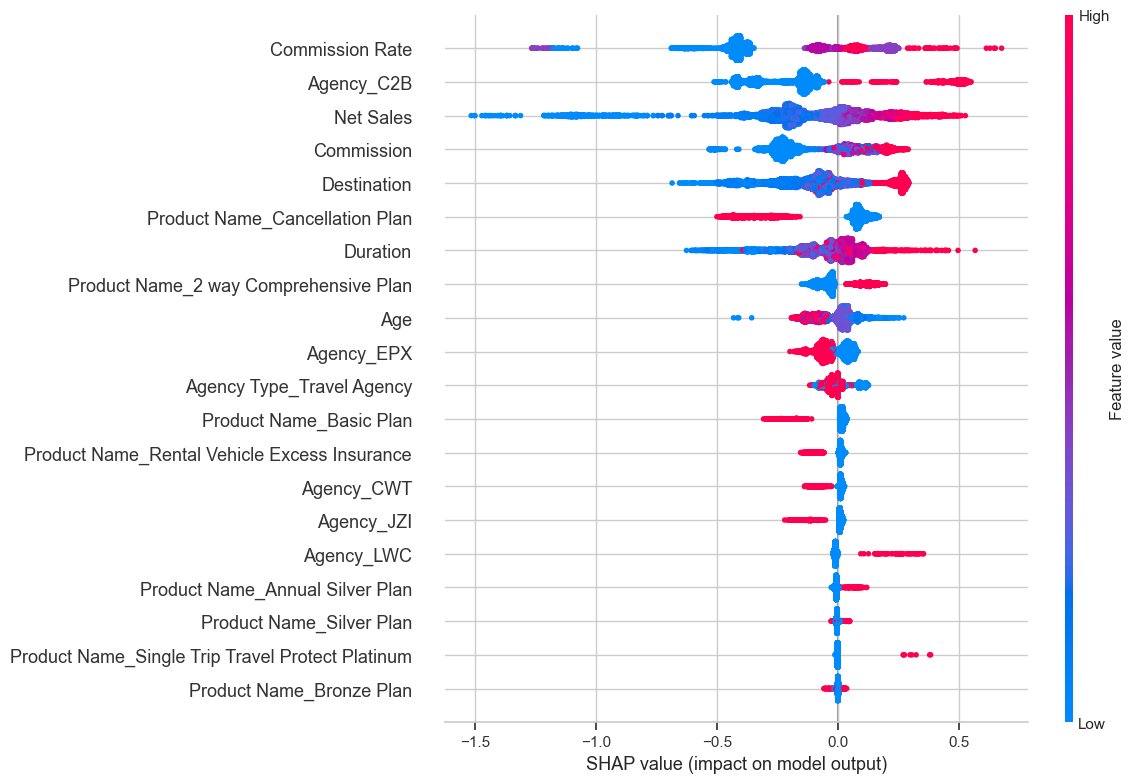

In [393]:
plt.figure(figsize=(12, 8))

shap.summary_plot(
    shap_values,
    x_test_transformed,
    feature_names=features_names,
    show=False
)

plt.gcf().set_size_inches(12, 8)
plt.tight_layout()
plt.show()